In [9]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

In [10]:
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']

cst_wm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_WM', 'summary_MNISymC_CST_WM_mod.tsv'), sep = '\t')
cerebel_gm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')

# just patients
cst_wm = cst_wm[cst_wm.isPatient == 1]
cerebel_gm = cerebel_gm[cerebel_gm.isPatient == 1]

cerebel_gm = cerebel_gm[cerebel_gm.regionname.isin(regions)]

cst_wm['hemisphere'] = cst_wm.regionname.str[0].astype(str).str.upper()
cerebel_gm['hemisphere'] = cerebel_gm.regionname.str[2]



# weeks to correlate
cst_week = 52
cerebel_week = 0

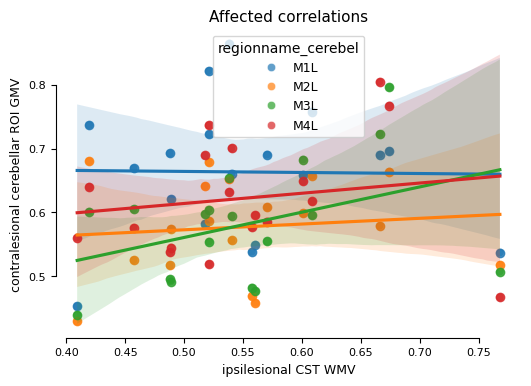

In [11]:
# affected: ipsilesional CST, contralesional cerebellum

right_cst = cst_wm[(cst_wm.hemisphere == 'R') & (cst_wm.Week == cst_week)] # ipsilesional CST
left_cerebel = cerebel_gm[(cerebel_gm.hemisphere == 'L') & (cerebel_gm.Week == cerebel_week)] # contralesional cerebellum
aff_df = pd.merge(right_cst, left_cerebel, on = ['subj_id'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (6,4))
sns.scatterplot(x = aff_df['mean_cst'], y = aff_df['mean_cerebel'], hue = aff_df['regionname_cerebel'], alpha = .7, ax = ax)
# add best fit line for each region individually
for region in aff_df.regionname_cerebel.unique():
    sns.regplot(data = aff_df[aff_df.regionname_cerebel == region], x = 'mean_cst', y = 'mean_cerebel',  ax = ax)

plt.xlabel('ipsilesional CST WMV')
plt.ylabel('contralesional cerebellar ROI GMV')
plt.title("Affected correlations")

sns.despine(trim = True)
plt.show()

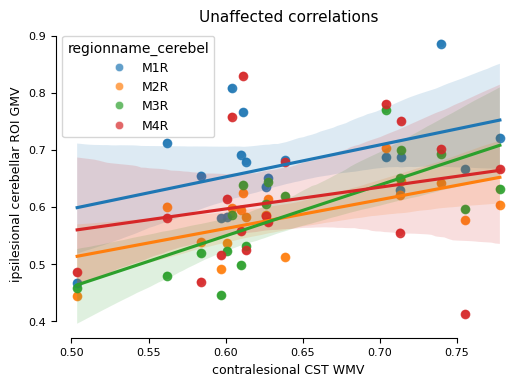

In [12]:
# unaffected: contralesional CST, ipsilesional cerebellum

left_cst = cst_wm[(cst_wm.hemisphere == 'L') & (cst_wm.Week == cst_week)] # contralesional CST
right_cerebel = cerebel_gm[(cerebel_gm.hemisphere == 'R') & (cerebel_gm.Week == cerebel_week)] # ipsilesional cerebellum
uanff_df = pd.merge(left_cst, right_cerebel, on = ['subj_id'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (6,4))
sns.scatterplot(x = uanff_df['mean_cst'], y = uanff_df['mean_cerebel'], hue = uanff_df['regionname_cerebel'], alpha = .7, ax = ax)
# add best fit line for each region individually
for region in uanff_df.regionname_cerebel.unique():
    sns.regplot(data = uanff_df[uanff_df.regionname_cerebel == region], x = 'mean_cst', y = 'mean_cerebel',  ax = ax)

plt.xlabel('contralesional CST WMV')
plt.ylabel('ipsilesional cerebellar ROI GMV')
plt.title("Unaffected correlations")

sns.despine(trim = True)
plt.show()